# Phoenix vs Polarism Benchmark Data Generation

This notebook generates reference data from PHOENIX for benchmarking against Polarism.
Run this notebook inside a Docker container with pyphoenix installed.

You can use command:

```docker run -it --gpus=all -p 8888:8888 robertschade/phoenix:latest```

## Physics Parameters
- Grid: 200x200, L=20µm (periodic boundaries)
- Effective mass: m_eff = 0.5 * 5.864E-4 meV·ps²/µm²
- ℏ = 6.582119569E-4 meV·ps
- Polariton loss: γ_C = 0.1 ps⁻¹
- Reservoir loss: γ_R = 0.15 ps⁻¹
- Condensation rate: R = 0.003 µm²/ps
- Bare threshold: P_th = γ_C·γ_R/R = 5.0
- Polariton coupling: g_C = 6E-6 meV·µm²
- Reservoir coupling: g_R = 1.2E-5 meV·µm²

## Key Physics: Potential Lowers Threshold
- Trapping potentials (V < 0) confine polaritons
- This lowers the effective condensation threshold
- Case 2 (no potential): needs higher pump
- Case 3 (with potential): condenses with lower pump

In [90]:
import json
import os
import re
import shutil
from pathlib import Path
from timeit import default_timer as timer

import numpy as np
import matplotlib.pyplot as plt
import yaml

from pyphoenix import pyphoenix

In [ ]:
GRID_SIZE = 200
L_MAX = 20.0
DX = L_MAX / (GRID_SIZE - 1)
HBAR = 6.582119569e-4
M_EFF = 0.5 * 5.864e-4
GAMMA_C = 0.1
GAMMA_R = 0.15

R_COND = 0.003
G_C = 6e-6
G_R = 1.2e-5

INIT_EPS = 1e-7

DT_OUTPUT = 0.2

BASE_DIR = Path(".")

USE_GPU = True
PRECISION = "fp64"

In [ ]:
def create_grid():
    x = np.linspace(-L_MAX / 2, L_MAX / 2, GRID_SIZE, endpoint=True)
    y = np.linspace(-L_MAX / 2, L_MAX / 2, GRID_SIZE, endpoint=True)
    X, Y = np.meshgrid(x, y, indexing='xy')
    return X, Y


def load_reservoir_for_wavefunction(wf_path: Path) -> np.ndarray | None:
    res_path = wf_path.parent / wf_path.name.replace("wavefunction_plus", "reservoir_plus")
    if res_path.exists():
        try:
            data = np.loadtxt(res_path, comments="#")
            if data.shape[0] == 2 * GRID_SIZE:
                return data[:GRID_SIZE, :]
            return data
        except Exception:
            pass
    return None


def parse_wavefunction_file(f: Path) -> dict | None:
    try:
        data = np.loadtxt(f, comments="#")
        N = data.shape[0] // 2
        re_part = data[:N, :]
        im_part = data[N:, :]

        if np.any(~np.isfinite(re_part)) or np.any(~np.isfinite(im_part)):
            return None

        psi = re_part + 1j * im_part
        rho = np.abs(psi)**2

        nR = load_reservoir_for_wavefunction(f)
        if nR is None:
            nR = np.zeros_like(rho)

        return {'psi': psi, 'rho': rho, 'nR': nR, 'rho_max': float(rho.max())}
    except Exception as e:
        print(f"  Warning: Failed to load {f.name}: {e}")
        return None


def extract_rho_max_and_frames(result_dir: Path, case_dir: Path) -> None:
    timeoutput_dir = result_dir / "timeoutput"
    time_re = re.compile(r"wavefunction_plus_([0-9]+(?:\.[0-9]+)?)\.txt$")

    all_wf_files = []
    if timeoutput_dir.exists():
        all_wf_files = sorted(timeoutput_dir.glob("wavefunction_plus_*.txt"))
    print(f"  Found {len(all_wf_files)} wavefunction files in timeoutput/")

    frames = []
    nan_count = 0
    for f in all_wf_files:
        m = time_re.search(f.name)
        if not m:
            continue
        t = float(m.group(1))

        result = parse_wavefunction_file(f)
        if result is None:
            nan_count += 1
            continue

        result['t'] = t
        frames.append(result)

    if nan_count > 0:
        print(f"  Warning: Skipped {nan_count} frames with NaN/Inf values")

    psi_init_path = case_dir / "psi_init.txt"
    reservoir_init_path = case_dir / "reservoir_init.txt"
    if psi_init_path.exists():
        try:
            data = np.loadtxt(psi_init_path, comments="#")
            N = data.shape[0] // 2
            psi_init = data[:N, :] + 1j * data[N:, :]
            rho_init = np.abs(psi_init)**2

            if reservoir_init_path.exists():
                nR_init = np.loadtxt(reservoir_init_path, comments="#")
            else:
                nR_init = np.zeros_like(rho_init)

            frames.insert(0, {
                't': 0.0, 'psi': psi_init, 'rho': rho_init,
                'nR': nR_init, 'rho_max': float(rho_init.max()),
            })
        except Exception as e:
            print(f"  Warning: Could not load initial state: {e}")

    final_wf = result_dir / "wavefunction_plus.txt"
    if final_wf.exists():
        result = parse_wavefunction_file(final_wf)
        if result is not None:
            t_last = max(f['t'] for f in frames) if frames else 0.0
            already_have = any(abs(f['t'] - t_last) < 0.01 for f in frames if f['t'] > 0)
            if not already_have or True:
                pass
            result['t'] = t_last
            final_frame = result
        else:
            final_frame = None
    else:
        final_frame = None

    if not frames and final_frame is None:
        print(f"WARNING: No valid wavefunction outputs found")
        np.savetxt(case_dir / "rho_max.txt", np.zeros((0, 2)),
                   header="t_ps rho_max", fmt="%.6f %.12e")
        return

    frames.sort(key=lambda x: x['t'])

    print(f"  Extracted {len(frames)} valid frames, t=[{frames[0]['t']:.1f}, {frames[-1]['t']:.1f}] ps")
    
    nR_nonzero = sum(1 for f in frames if f['nR'].max() > 0)
    print(f"  Frames with non-zero nR: {nR_nonzero}/{len(frames)}")

    times = np.array([f['t'] for f in frames])
    rho_max = np.array([f['rho_max'] for f in frames])
    np.savetxt(case_dir / "rho_max.txt", np.column_stack([times, rho_max]),
               header="t_ps rho_max", fmt="%.6f %.12e")

    first_frame = frames[0]
    last_frame = final_frame if final_frame is not None else frames[-1]

    for label, frame in [("first", first_frame), ("last", last_frame)]:
        np.savez(
            case_dir / f"frame_{label}.npz",
            t=frame['t'],
            psi_real=frame['psi'].real,
            psi_imag=frame['psi'].imag,
            rho=frame['rho'],
            nR=frame['nR'],
        )

    print(f"  Saved: frame_first (t={first_frame['t']:.1f}), frame_last (t={last_frame['t']:.1f})")
    print(f"  Last frame nR: min={last_frame['nR'].min():.2e}, max={last_frame['nR'].max():.2e}")

In [ ]:
def run_phoenix_simulation(
    case_dir: Path,
    pump: np.ndarray,
    potential: np.ndarray,
    t_end: float,
    tstep: float = 0.001,
    use_gpu: bool = USE_GPU,
    precision: str = PRECISION,
    noise_seed: int = 42,
    noise_amplitude: float = 1e-2,
) -> dict:
    case_dir = Path(case_dir).resolve()
    case_dir.mkdir(parents=True, exist_ok=True)
    
    pump_path = case_dir / "pump.txt"
    pot_path = case_dir / "potential.txt"
    psi_init_path = case_dir / "psi_init.txt"
    reservoir_init_path = case_dir / "reservoir_init.txt"
    
    header = f"SIZE {GRID_SIZE} {GRID_SIZE} {L_MAX} {L_MAX} {DX} {DX} PYTHON-GENERATED"
    np.savetxt(pump_path, pump, header=header, fmt='%.15e')
    np.savetxt(pot_path, potential, header=header, fmt='%.15e')
    
    rng = np.random.default_rng(noise_seed)
    noise_re = rng.normal(0, noise_amplitude, (GRID_SIZE, GRID_SIZE))
    noise_im = rng.normal(0, noise_amplitude, (GRID_SIZE, GRID_SIZE))
    psi_init_re = INIT_EPS * (1.0 + noise_re)
    psi_init_im = INIT_EPS * noise_im
    psi_init_stacked = np.vstack([psi_init_re, psi_init_im])
    np.savetxt(psi_init_path, psi_init_stacked, header=header, fmt='%.15e')
    
    reservoir_init = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float64)
    np.savetxt(reservoir_init_path, reservoir_init, header=header, fmt='%.15e')
    
    cfg = {
        "N": [GRID_SIZE, GRID_SIZE],
        "L": [L_MAX, L_MAX],
        "meff": M_EFF,
        "tmax": t_end,
        "tstep": tstep,
        "outEvery": DT_OUTPUT,
        "gc": G_C,
        "gr": G_R,
        "R": R_COND,
        "gammaR": GAMMA_R,
        "gammaC": GAMMA_C,
        "boundary": ["periodic", "periodic"],
    }
    
    cfg["pump"] = ["load", str(pump_path), 1, "add", "both"]
    
    cfg["initialState"] = ["load", str(psi_init_path), 1, "add", "both"]
    
    cfg["initialReservoir"] = ["load", str(reservoir_init_path), 1, "add", "both"]
    
    cfg["potential"] = ["load", str(pot_path), 1, "add", "both"]
    
    cfg["output"] = "mat"
    cfg["historyMatrix"] = [0, GRID_SIZE, 0, GRID_SIZE, 1]
    cfg["historyTime"] = [0, 1]
    
    device = "GPU" if use_gpu else "CPU"
    print(f"Running PHOENIX [{device}]: {case_dir.name}, t_end={t_end} ps, tstep={tstep} ps")
    
    start_time = timer()
    
    ph = pyphoenix.pyphoenix(
        debug=False,
        precision=precision, 
        doprint=False,
        use_gpu=use_gpu
    )
    ph.run(cfg)
    
    elapsed = timer() - start_time
    print(f"  Elapsed: {elapsed:.2f} s")
    
    result_dir = Path(ph.get_result_path())
    
    extract_rho_max_and_frames(result_dir, case_dir)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(pump, origin="lower", extent=[-L_MAX/2, L_MAX/2, -L_MAX/2, L_MAX/2])
    axes[0].set_title("Pump")
    fig.colorbar(im0, ax=axes[0])
    im1 = axes[1].imshow(potential, origin="lower", extent=[-L_MAX/2, L_MAX/2, -L_MAX/2, L_MAX/2])
    axes[1].set_title("Potential")
    fig.colorbar(im1, ax=axes[1])
    plt.tight_layout()
    fig.savefig(case_dir / "inputs.png", dpi=150)
    plt.close(fig)
    
    timing_info = {
        "case": case_dir.name,
        "elapsed_s": elapsed,
        "t_end_ps": t_end,
        "tstep_ps": tstep,
        "precision": precision,
        "device": device,
    }
    with open(case_dir / "timing.json", "w") as f:
        json.dump(timing_info, f, indent=2)
    
    return timing_info

In [ ]:
def generate_lasers_yaml(case_dir: Path, laser_configs: list) -> None:
    yaml_content = {"lasers": laser_configs}
    yaml_path = case_dir / "phoenix_lasers_setup.yaml"
    with open(yaml_path, "w") as f:
        yaml.dump(yaml_content, f, default_flow_style=False)

## Case 1: Uniform Pump, No Potential

- Uniform pump P₀ = 12.0 (2.4× threshold)
- No potential (V = 0)
- t = 500 ps

In [ ]:
X, Y = create_grid()

case1_dir = BASE_DIR / "01_uniform_pump"
P0_UNIFORM = 12.0

pump1 = np.full_like(X, P0_UNIFORM, dtype=np.float64)
potential1 = np.zeros_like(X, dtype=np.float64)

result1 = run_phoenix_simulation(
    case_dir=case1_dir,
    pump=pump1,
    potential=potential1,
    t_end=500.0,
)

generate_lasers_yaml(case1_dir, [
    {"laser_type": "uniform", "P0": P0_UNIFORM, "x0": 0.0, "y0": 0.0}
])

print(f"Case 1 complete: {result1}")

## Case 2: Exponential Pumps, No Potential

- Two exponential pumps at x = ±2 µm
- P₁ = 8, P₂ = 10, σ = 2.5 µm
- V = 0
- t = 1000 ps

In [ ]:
case2_dir = BASE_DIR / "02_pump_no_potential"

SPACING = 4.0

P1_AMP_NOPOT, P1_SIGMA_NOPOT = 8, 2.5  
P2_AMP_NOPOT, P2_SIGMA_NOPOT = 10, 2.5

r1 = np.sqrt((X + SPACING / 2) ** 2 + Y ** 2)
r2 = np.sqrt((X - SPACING / 2) ** 2 + Y ** 2)

pump2 = (P1_AMP_NOPOT * np.exp(-r1 / P1_SIGMA_NOPOT**2) 
       + P2_AMP_NOPOT * np.exp(-r2 / P2_SIGMA_NOPOT**2))
potential2 = np.zeros_like(X, dtype=np.float64)

result2 = run_phoenix_simulation(
    case_dir=case2_dir,
    pump=pump2,
    potential=potential2,
    t_end=1000.0,
)

generate_lasers_yaml(case2_dir, [
    {"laser_type": "continuous-exp", "P0": P1_AMP_NOPOT, "x0": -SPACING/2, "y0": 0.0, "sigma_space": P1_SIGMA_NOPOT},
    {"laser_type": "continuous-exp", "P0": P2_AMP_NOPOT, "x0": SPACING/2, "y0": 0.0, "sigma_space": P2_SIGMA_NOPOT},
])

print(f"Case 2 complete: {result2}")

Running PHOENIX [GPU]: 02_pump_no_potential, t_end=1000.0 ps, tstep=0.001 ps
  Elapsed: 43.01 s
  Found 5000 wavefunction files
  Extracted 5001 valid frames, t=[0.0, 1000.0] ps
  Saved frames: t_first=0.0 ps, t_last=1000.0 ps
Case 2 complete: {'case': '02_pump_no_potential', 'elapsed_s': 43.006720444000166, 't_end_ps': 1000.0, 'tstep_ps': 0.001, 'precision': 'fp32', 'device': 'GPU'}


## Case 3: Gaussian Pumps + Double-Well Potential

- Two Gaussian pumps at x = ±3 µm, σ = 3 µm
- P₁ = 6, P₂ = 9
- Gaussian wells (order=1): V₁ = -0.3, V₂ = -0.35 meV, w = 4 µm
- t = 1000 ps

Gaussian pumps are smoother than exponential and resolve better on the
discrete grid, giving tighter agreement between Phoenix and Polarism.

In [ ]:
case3_dir = BASE_DIR / "03_pump_and_potential"

PUMP_SPACING = 3.0
P1_AMP, P2_AMP = 6.0, 9.0
SIGMA_PUMP = 3.0

r1_sq = (X + PUMP_SPACING) ** 2 + Y ** 2
r2_sq = (X - PUMP_SPACING) ** 2 + Y ** 2

pump3 = (P1_AMP * np.exp(-0.5 * r1_sq / SIGMA_PUMP**2)
       + P2_AMP * np.exp(-0.5 * r2_sq / SIGMA_PUMP**2))

V1, V2 = -0.3, -0.35
W_POT = 4.0            

potential3 = (
    V1 * np.exp(-(r1_sq / W_POT**2))
    + V2 * np.exp(-(r2_sq / W_POT**2))
)

print(f"Potential range: [{potential3.min():.4f}, {potential3.max():.4f}] meV")
print(f"Pump max: {pump3.max():.2f}")

result3 = run_phoenix_simulation(
    case_dir=case3_dir,
    pump=pump3,
    potential=potential3,
    t_end=1000.0,
)

generate_lasers_yaml(case3_dir, [
    {"laser_type": "continuous-gaussian", "P0": P1_AMP, "x0": -PUMP_SPACING, "y0": 0.0, "sigma_space": SIGMA_PUMP},
    {"laser_type": "continuous-gaussian", "P0": P2_AMP, "x0": PUMP_SPACING, "y0": 0.0, "sigma_space": SIGMA_PUMP},
])

print(f"Case 3 complete: {result3}")

## Results

In [ ]:
print("=" * 60)
print("BENCHMARK DATA GENERATION COMPLETE")
print("=" * 60)

for case_dir in [case1_dir, case2_dir, case3_dir]:
    print(f"\n{case_dir.name}:")
    expected_files = [
        "pump.txt", "potential.txt", "psi_init.txt", "reservoir_init.txt",
        "rho_max.txt", "frame_first.npz", "frame_last.npz",
        "timing.json", "phoenix_lasers_setup.yaml", "inputs.png"
    ]
    for fname in expected_files:
        fpath = case_dir / fname
        status = "OK" if fpath.exists() else "MISSING"
        print(f"  {status} {fname}")

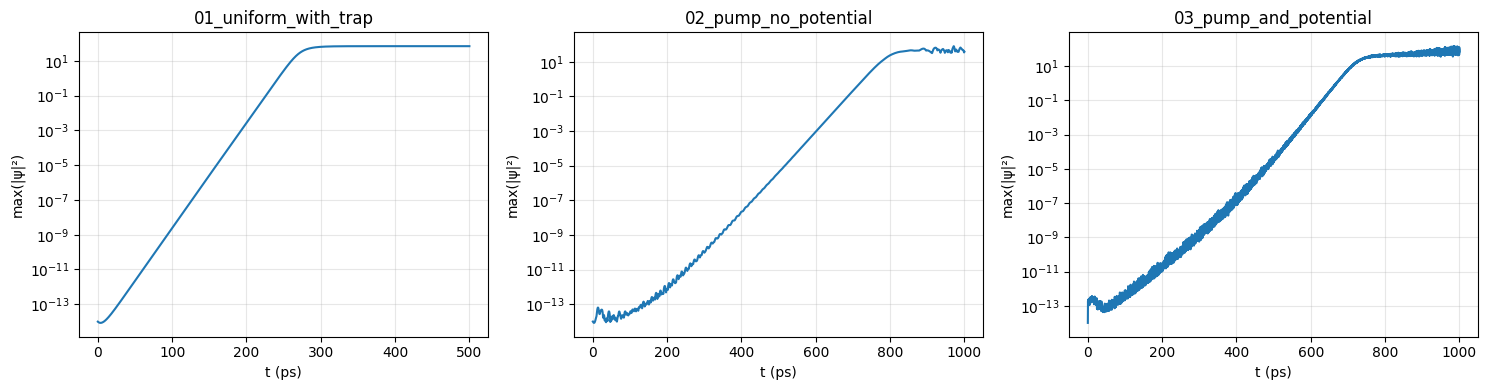

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, case_dir in zip(axes, [case1_dir, case2_dir, case3_dir]):
    rho_path = case_dir / "rho_max.txt"
    if not rho_path.exists():
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(case_dir.name)
        continue
        
    rho_data = np.loadtxt(rho_path, comments="#")
    if rho_data.size == 0:
        ax.text(0.5, 0.5, "Empty", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(case_dir.name)
        continue
    
    if rho_data.ndim == 1:
        rho_data = rho_data.reshape(1, -1)
    
    t, rho = rho_data[:, 0], rho_data[:, 1]
    ax.semilogy(t, rho)
    ax.set_xlabel("t (ps)")
    ax.set_ylabel("max(|ψ|²)")
    ax.set_title(case_dir.name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_DIR / "benchmark_summary.png", dpi=150)
plt.show()

In [ ]:
print("\nTiming Summary:")
print(f"{'Case':<25} {'Device':<8} {'Time (s)':<12} {'Sim (ps)':<10}")
print("-" * 60)
for r in [result1, result2, result3]:
    print(f"{r['case']:<25} {r['device']:<8} {r['elapsed_s']:<12.2f} {r['t_end_ps']:<10.1f}")


Timing Summary:
Case                      Device   Time (s)     Sim (ps)  
------------------------------------------------------------
01_uniform_with_trap      GPU      21.48        500.0     
02_pump_no_potential      GPU      43.01        1000.0    
03_pump_and_potential     GPU      43.29        1000.0    
